# Notebook to generate the article's figures

In this notebook, the code used to create Figures 5, 6, 7 and 10 is present. The other Figures were created through different methods (QGIS, hand drawing) and only their final version is shared in _figures_ folder.

# Setup

In [2]:
import matplotlib.dates as mdates
import matplotlib.patheffects as pe
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import re
import seaborn as sns
import sys

In [3]:
def cm2inch(*tupl):
    """
    Transforms centrimeters to inches
    """
    inch = 2.54
    if isinstance(tupl[0], tuple):
        return tuple(i/inch for i in tupl[0])
    else:
        return tuple(i/inch for i in tupl)
    
def is_pareto_efficient_simple(costs):
    """
    From: https://stackoverflow.com/a/40239615
    Find the pareto-efficient points
    :param costs: An (n_points, n_costs) array
    :return: A (n_points, ) boolean array, indicating whether each point is Pareto efficient
    """
    is_efficient = np.ones(costs.shape[0], dtype = bool)
    for i, c in enumerate(costs):
        if is_efficient[i]:
            is_efficient[is_efficient] = np.any(costs[is_efficient]<c, axis=1)  # Keep any point with a lower cost
            is_efficient[i] = True  # And keep self
    return is_efficient

In [4]:
cwd = '\\'.join(os.getcwd().split('\\')[:-2])
cwd

'c:\\repos\\fontanile_model'

# Figures

## Fgiure 5 - K calibration DRN

In [77]:
drn_k = pd.read_excel(os.path.join(cwd, 'output_data', 'drain_results_multipar_lidar_asta.xlsx'))
drn_k = drn_k.iloc[:,1:8]

In [78]:
drn_k['abs_diff'] = abs(drn_k.drn_until_rc - 0.019)*1000

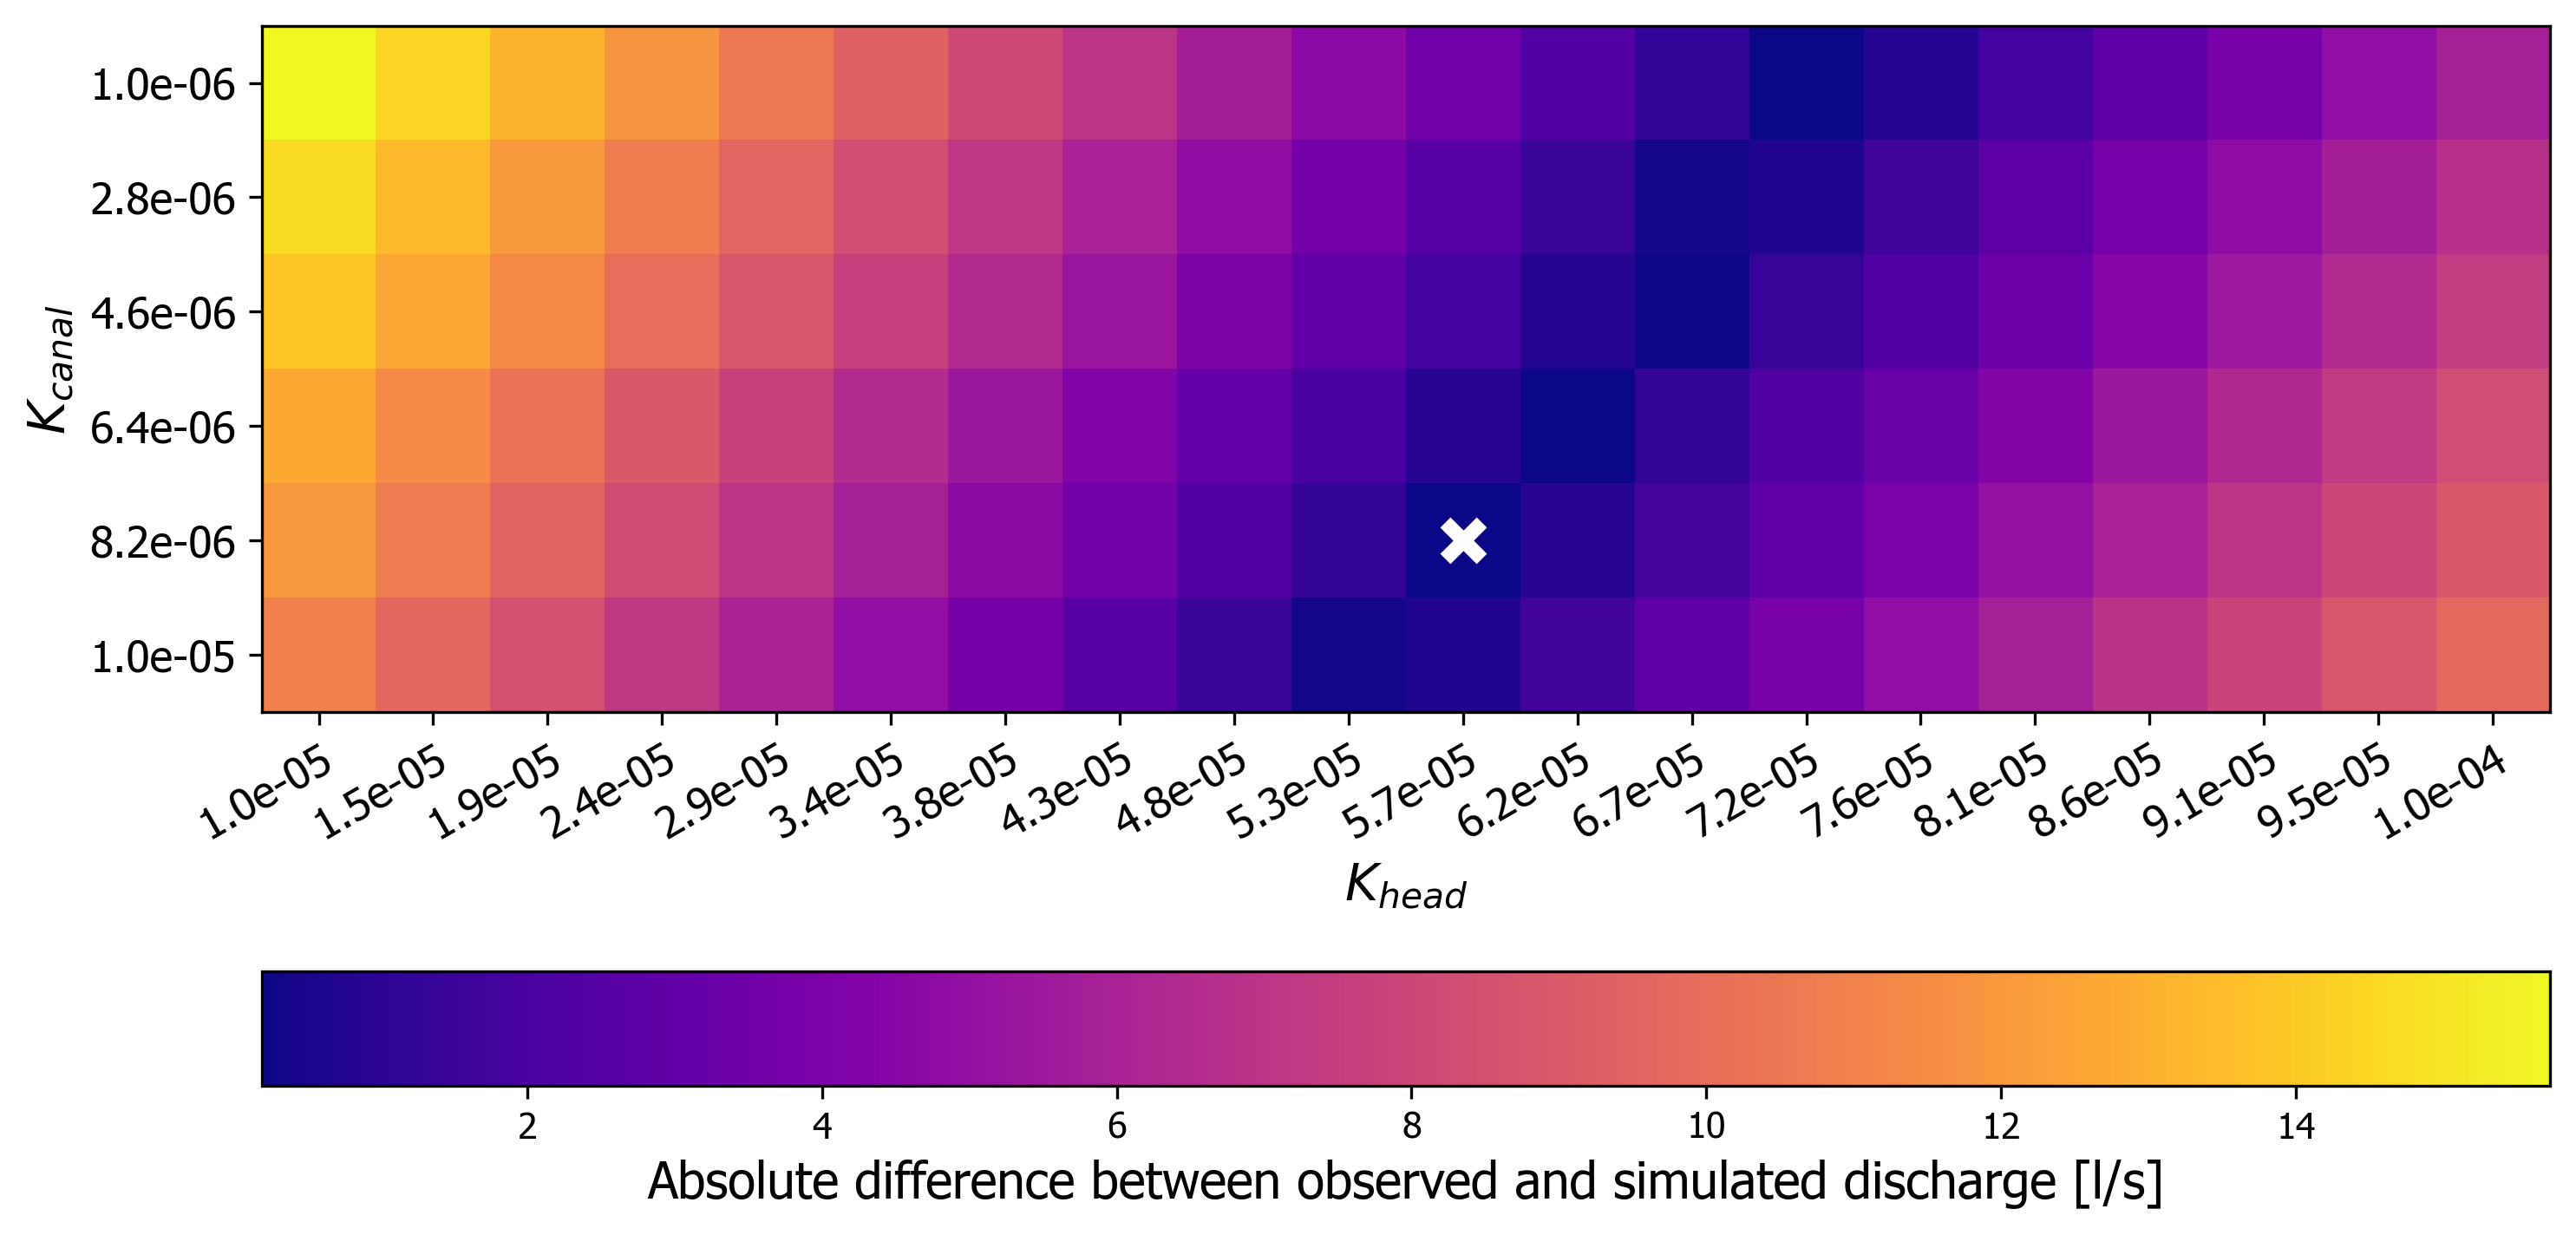

In [80]:
tool = drn_k.pivot_table(index='ka',columns='kt',values='abs_diff')
fig, ax = plt.subplots(1,1,figsize = (10,7), dpi = 300)
im = ax.imshow(tool, cmap='plasma')
cbar = ax.figure.colorbar(im, ax = ax, orientation = 'horizontal', location = 'bottom')
cbar.ax.set_xlabel('Absolute difference between observed and simulated discharge [l/s]',
                   rotation=0, va = "top", size = 14)

ax.set_yticks(np.arange(tool.shape[0]), labels = ['{:.1e}'.format(x) for x in tool.index])
ax.set_xticks(np.arange(tool.shape[1]), labels = ['{:.1e}'.format(x) for x in tool.columns])
ax.tick_params(labelsize = 12)

ax.set_ylabel('$K_{canal}$', size = 14)
ax.set_xlabel('$K_{head}$', size = 14)

ax.plot(10, 4, marker = 'x', ms = 10, mew = 4, color = 'white')

plt.setp(ax.get_xticklabels(), rotation = 30, ha = "right",
        rotation_mode = "anchor")


fig.tight_layout()
fig.savefig(os.path.join(cwd, 'figures', 'Figure_5.png'), bbox_inches = 'tight', dpi = 300)

## Figure 8e - Lowland springs hydrograph

In [125]:
ls_1 = pd.read_excel(os.path.join(cwd, 'output_data', 'large_model', 'reach_report_WIRR_scenario_tutti_SP.xlsx'), sheet_name='645')
ls_2 = pd.read_excel(os.path.join(cwd, 'output_data', 'large_model', 'reach_report_WIRR_scenario_tutti_SP.xlsx'), sheet_name='618')
ls_3 = pd.read_excel(os.path.join(cwd, 'output_data', 'large_model', 'reach_report_WIRR_scenario_tutti_SP.xlsx'), sheet_name='580')

ls_1 = ls_1.iloc[:, :-1]
ls_2 = ls_2.iloc[:, :-2]
ls_3 = ls_3.iloc[:, :-2]

sp = [[i]*5 for i in range(2,21)]
sp = [val for sublist in sp for val in sublist]
sp.append(20)
# sp.insert(0, 1)

df = pd.DataFrame()
lss = [ls_1, ls_2, ls_3]
tags = ['Upstream', 'Central', 'Downstream']
for i, ls in enumerate(lss):
    ls['tag'] = tags[i]
    ls['sp'] = sp
    df = pd.concat([df, ls])
df = df.melt(id_vars=['sp', 'Time Step', 'tag'])

var_dict = {
    'Q_drain_RUN0_ass': 'Base',
    'Q_drain_WIRR_ass': 'Scenario 1',
    'Q_drain_WIRR_ass_scenario': 'Scenario 2'
}
df.variable = [var_dict[i] for i in df.variable]
df.value = df.value * 1000
df.columns = ['sp', 'ts', 'Lowland spring location', 'Scenarios', 'discharge_ls']

In [126]:
tool = ls_1.loc[:, ['sp', 'Time Step']].copy()
tool.columns = ['sp', 'ts']

In [137]:
sp_plot = []
for i in range(2,21):
    sp_plot.append([i, min(tool.loc[tool.sp == i, 'ts'])])
sp_plot.insert(0, [1,0])
sp_plot = pd.DataFrame(sp_plot, columns=['label', 'position'])

In [156]:
sp_plot.loc[sp_plot.label.isin([8,9,12,13])]

,label,position
7,8,31
8,9,36
11,12,51
12,13,56


In [132]:
from matplotlib.patches import Rectangle
# https://matplotlib.org/stable/api/_as_gen/matplotlib.patches.Rectangle.html#matplotlib.patches.Rectangle

In [ ]:
['#240E31FF', '#CB6BCEFF', '#468892FF', '#74F3D3FF', '#751C6DFF', '#FDC067FF', '#AC9ECEFF','#6EC5ABFF']

C:\Users\user\AppData\Local\Temp\ipykernel_8996\2406791366.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize = 14);


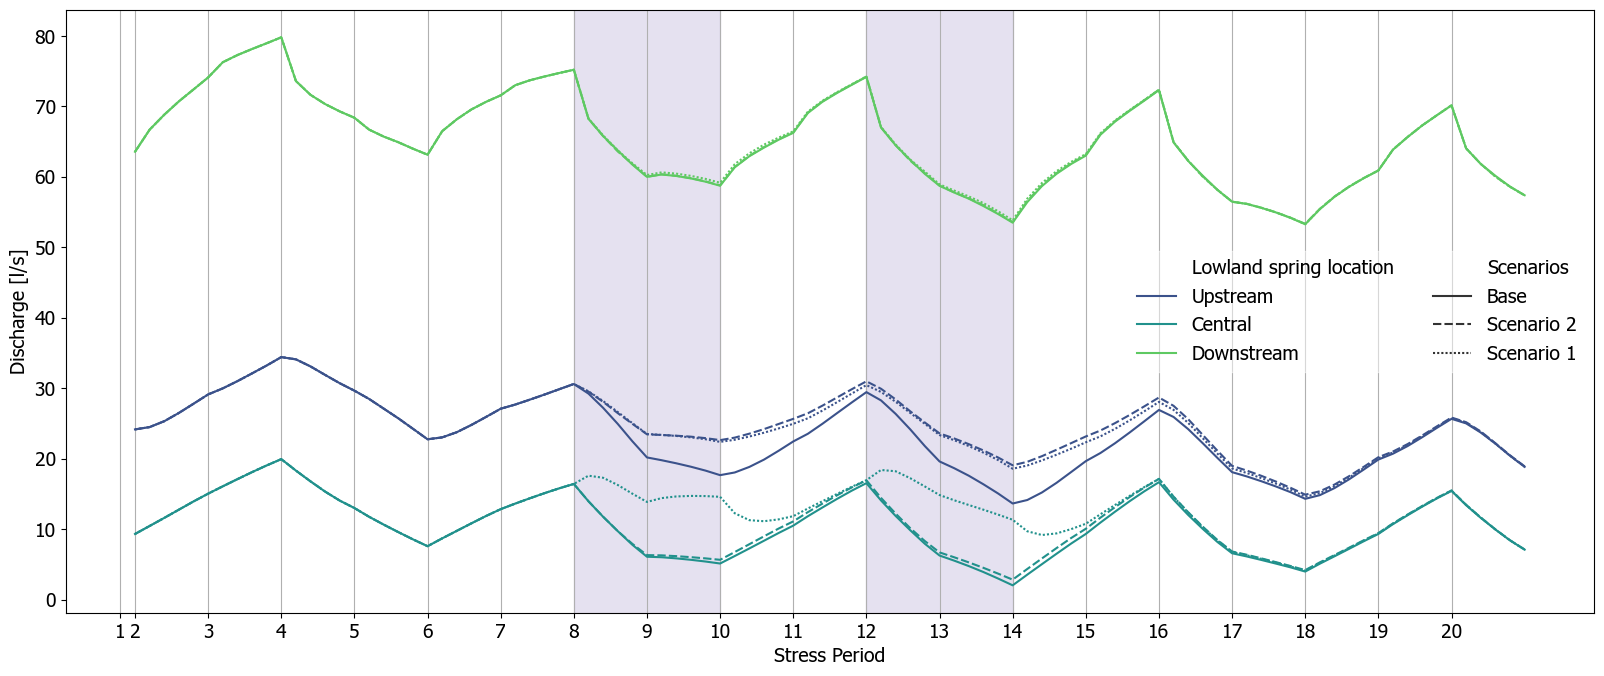

In [158]:
fig, ax = plt.subplots(1,1,figsize = cm2inch(16.6995*3,6.6283*3))
sns.lineplot(df, x = 'ts', y = 'discharge_ls', hue = 'Lowland spring location', style = 'Scenarios', ax = ax, palette='viridis')
ax.set_ylabel('Discharge [l/s]', fontsize = 14)
ax.set_xlabel('Stress Period', fontsize = 14)
ax.grid(axis = 'x')
ax.set_xticks(sp_plot.position);
ax.set_xticklabels(sp_plot.label, fontsize = 14);
ax.set_yticklabels(ax.get_yticklabels(), fontsize = 14);

ax.legend(fontsize = 14, frameon = True, ncols = 2, edgecolor = 'w', framealpha = 0.5)

plt.gca().add_patch(Rectangle((31, -10), 10, 100, alpha = 0.3, color = '#AC9ECEFF'))
plt.gca().add_patch(Rectangle((51, -10), 10, 100, alpha = 0.3, color = '#AC9ECEFF'))
plt.rcParams['font.family'] = 'Tahoma'

fig.savefig(os.path.join(cwd, 'figures', 'Figure_8e.png'), bbox_inches = 'tight', dpi = 300)

## Figure 6 - Pareto frontier of SFR and SFR+LAK

In [137]:
mres = pd.read_csv(os.path.join(cwd, 'output_data', 'sfr_laksfr_complete_results_v3.csv'))
mres = mres.astype({"model": str,
             "package": str,
             "geom": str,
             "elev": str})
mres['code'] = [f'{m}_{p}' for m,p in zip(mres.model, mres.package)]

paretoidx = is_pareto_efficient_simple(mres.loc[:, ['flow_perc_err','depth_perc_err']].values)
pareto_front = mres.iloc[paretoidx,:].reset_index(drop=True).copy()

In [6]:
mres.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22937 entries, 0 to 22936
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   model              22937 non-null  object 
 1   package            22937 non-null  object 
 2   kt                 13750 non-null  float64
 3   ka                 13750 non-null  float64
 4   st_coeff           12500 non-null  float64
 5   sa_coeff           13750 non-null  float64
 6   n                  13750 non-null  float64
 7   flow_out_reach     13750 non-null  float64
 8   stream_depth       13750 non-null  float64
 9   geom               22937 non-null  object 
 10  icalc              13750 non-null  float64
 11  elev               22937 non-null  object 
 12  flow_diff          13750 non-null  float64
 13  depth_diff         13750 non-null  float64
 14  flow_perc_err      13750 non-null  float64
 15  depth_perc_err     13750 non-null  float64
 16  combined_perc_err  137

C:\Users\user\AppData\Local\Temp\ipykernel_9124\2807572589.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, fontsize = 12)
C:\Users\user\AppData\Local\Temp\ipykernel_9124\2807572589.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels, fontsize = 12)
C:\Users\user\AppData\Local\Temp\ipykernel_9124\2807572589.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, fontsize = 12)
C:\Users\user\AppData\Local\Temp\ipykernel_9124\2807572589.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels, fontsize = 12)
C:\Users\user\AppData\Local\Temp\ipykernel_9124\

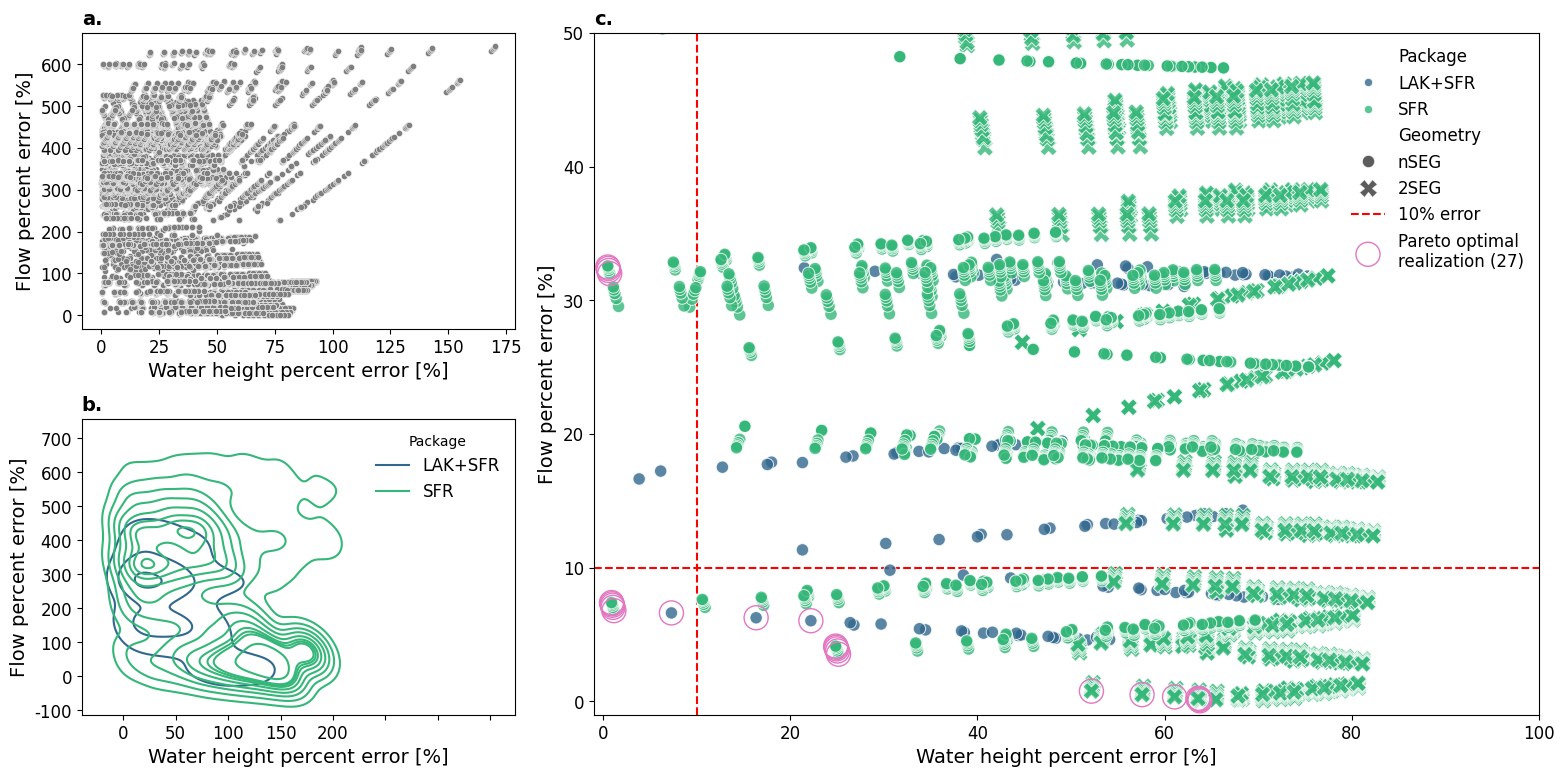

In [ ]:
fig = plt.figure(figsize = cm2inch(20*2, 10*2))

gs = fig.add_gridspec(2, 3)
ax1 = fig.add_subplot(gs[0,0])
ax2 = fig.add_subplot(gs[:,1:])
ax3 = fig.add_subplot(gs[1,0])
# ax4 = fig.add_subplot(gs[1,1:])

sns.scatterplot(mres, x = 'depth_perc_err', y = 'flow_perc_err', ax = ax1, zorder = 2, color = 'tab:grey', s = 20)

sns.kdeplot(mres, x = 'depth_perc_err', y = 'flow_perc_err', hue = 'package', ax = ax3, palette = 'viridis')

sns.scatterplot(mres, x = 'depth_perc_err', y = 'flow_perc_err', hue = "package", style = 'geom', size = 'geom', ax = ax2, zorder = 2, palette = 'viridis', sizes=(150, 80), alpha = 0.8)

# ax2.axvline(0.1, color = 'r', zorder = 1)
ax2.axvline(0.1, color = 'r', linestyle = '--', zorder = 1, label = '10% error')
ax2.axhline(0.1, color = 'r', linestyle = '--', zorder = 1)
# ax2.axhline(0.1, color = 'r', linestyle = '-', zorder = 1)

ax2.set_xlim(-0.01,1)
ax2.set_ylim(-0.01,0.5)

ax2.scatter(pareto_front.depth_perc_err.values, pareto_front.flow_perc_err.values, marker = 'o', facecolors='none',
           edgecolors='tab:pink', s = 300, alpha=1, label=f'Pareto optimal\nrealization ({pareto_front.shape[0]})',
           zorder = 3)

titles = ['a.', 'c.', 'b.']
for i, ax in enumerate([ax1, ax2, ax3]):
    ax.set_title(titles[i], loc ='left', fontweight = 'bold', fontsize = 14)

    ax.set_xlabel('Water height percent error [%]', fontsize = 14)
    labels = [str(round(float(re.sub(r'[^\x00-\x7F]+', '-', item.get_text()))*100)) for item in ax.get_xticklabels()]
    ax.set_xticklabels(labels, fontsize = 12)
    
    ax.set_ylabel('Flow percent error [%]', fontsize = 14)
    labels = [str(round(float(re.sub(r'[^\x00-\x7F]+', '-', item.get_text()))*100)) for item in ax.get_yticklabels()]
    ax.set_yticklabels(labels, fontsize = 12)

# Set legends

labels = ['Package' if x == 'package' else x for x in ax2.get_legend_handles_labels()[1]]
labels = ['Geometry' if x == 'geom' else x for x in labels]
ax2.legend(ax2.get_legend_handles_labels()[0], labels, frameon = False, fancybox = False, fontsize = 12, loc = 'upper right', facecolor = 'white', framealpha = 1,
           title_fontsize=14)

legend = ax3.get_legend()
handles = legend.legend_handles
labels = [t.get_text() for t in legend.get_texts()]
legend.remove()
ax3.legend(
    handles,
    labels,
    title='Package',
    loc='upper right',
    fontsize = 12,
    frameon=False
)

fig.tight_layout()

fig.savefig(os.path.join(cwd, 'figures', 'Figure_6_new.png'), dpi = 300,bbox_inches = 'tight')

## Figure 9 - KDE plots by parameters

In [ ]:
mres = pd.read_csv(os.path.join(cwd, 'output_data', 'sfr_laksfr_complete_results_v3.csv'))
mres = mres.astype({"model": str,
             "package": str,
             "geom": str,
             "elev": str})
mres['code'] = [f'{m}_{p}' for m,p in zip(mres.model, mres.package)]

paretoidx = is_pareto_efficient_simple(mres.loc[:, ['flow_perc_err','depth_perc_err']].values)
pareto_front = mres.iloc[paretoidx,:].reset_index(drop=True).copy()

C:\Users\user\AppData\Local\Temp\ipykernel_18116\1844403684.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_yticklabels(labels, fontsize = 10)
C:\Users\user\AppData\Local\Temp\ipykernel_18116\1844403684.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(labels, fontsize = 10)


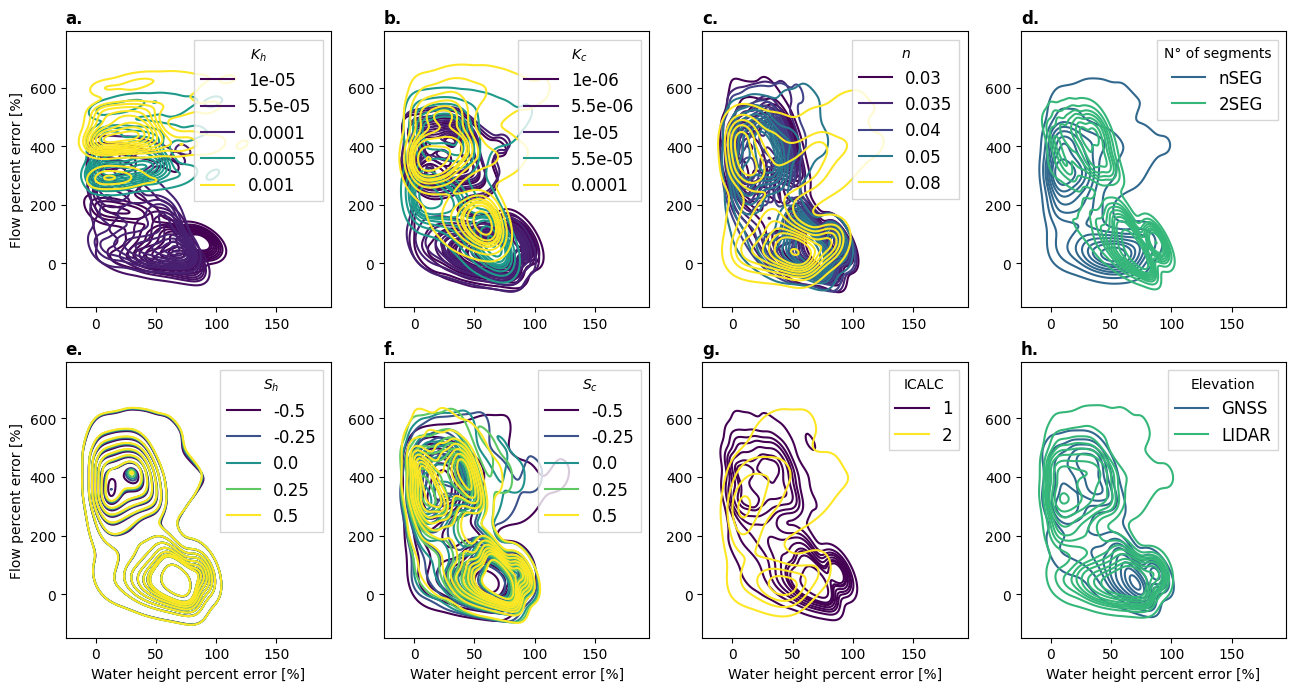

In [5]:
fig = plt.figure(figsize = cm2inch(20*2, 10*2))

gs = fig.add_gridspec(2, 4)
ax1 = fig.add_subplot(gs[0,0])
ax2 = fig.add_subplot(gs[0,1], sharex=ax1, sharey=ax1)
ax3 = fig.add_subplot(gs[1,0], sharex=ax1, sharey=ax1)
ax4 = fig.add_subplot(gs[1,1], sharex=ax1, sharey=ax1)
ax5 = fig.add_subplot(gs[0,2], sharex=ax1, sharey=ax1)
ax6 = fig.add_subplot(gs[1,2], sharex=ax1, sharey=ax1)
ax7 = fig.add_subplot(gs[0,3], sharex=ax1, sharey=ax1)
ax8 = fig.add_subplot(gs[1,3], sharex=ax1, sharey=ax1)

#1, 2, 5, 7 
#3, 4, 6, 8

sns.kdeplot(mres, x = 'depth_perc_err', y = 'flow_perc_err', hue = "kt", ax = ax1, zorder = 2, palette = 'viridis')
sns.kdeplot(mres, x = 'depth_perc_err', y = 'flow_perc_err', hue = "ka", ax = ax2, zorder = 2, palette = 'viridis')
sns.kdeplot(mres, x = 'depth_perc_err', y = 'flow_perc_err', hue = "st_coeff", ax = ax3, zorder = 2, palette = 'viridis')
sns.kdeplot(mres, x = 'depth_perc_err', y = 'flow_perc_err', hue = "sa_coeff", ax = ax4, zorder = 2, palette = 'viridis')
sns.kdeplot(mres, x = 'depth_perc_err', y = 'flow_perc_err', hue = "n", ax = ax5, zorder = 2, palette = 'viridis')
sns.kdeplot(mres, x = 'depth_perc_err', y = 'flow_perc_err', hue = "icalc", ax = ax6, zorder = 2, palette = 'viridis')

sns.kdeplot(mres, x = 'depth_perc_err', y = 'flow_perc_err', hue = "geom", ax = ax7, zorder = 2, palette = 'viridis')
sns.kdeplot(mres, x = 'depth_perc_err', y = 'flow_perc_err', hue = "elev", ax = ax8, zorder = 2, palette = 'viridis')


#Style
axes = [ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8]
titles = ['a.', 'b.', 'e.', 'f.', 'c.','g.','d.', 'h.']
#1, 2, 5, 7 
#3, 4, 6, 8
for i, ax in enumerate(axes, 1):
    if i in [2,4,5,7,6,8]:
        # ax.set_yticklabels('')
        ax.set_ylabel('')
    if i in [1,2,5,7]:
        # ax.set_xticklabels('')
        ax.set_xlabel('')
    if i in [1,3]:
        ax.set_ylabel('Flow percent error [%]')
    if i in [3,4,6,8]:
        ax.set_xlabel('Water height percent error [%]')
    ax.set_title(titles[i-1], loc ='left', fontweight = 'bold', fontsize = 12)

labels = [str(round(float(re.sub(r'[^\x00-\x7F]+', '-', item.get_text()))*100)) for item in ax1.get_yticklabels()]
ax1.set_yticklabels(labels, fontsize = 10)
labels = [str(round(float(re.sub(r'[^\x00-\x7F]+', '-', item.get_text()))*100)) for item in ax1.get_xticklabels()]
ax1.set_xticklabels(labels, fontsize = 10)

#Legends
renametitle = {
    'kt': '$K_{h}$',
    'ka': '$K_{c}$',
    'st_coeff': '$S_{h}$',
    'sa_coeff': '$S_{c}$',
    'geom': 'N° of segments',
    'icalc': 'ICALC',
    'elev': 'Elevation',
    'n': '$n$'
}
for ax in axes:
    legend = ax.get_legend()
    handles = legend.legend_handles
    labels = [t.get_text() for t in legend.get_texts()]
    title = ax.get_legend().get_title().get_text()
    legend.remove()
    ax.legend(
        handles,
        labels,
        title=renametitle[title],
        loc='upper right',
        fontsize = 12,
        frameon=True,
        fancybox = False
    )

fig.savefig(os.path.join(cwd, 'figures', 'Figure_9.png'), dpi = 300,bbox_inches = 'tight',)

kt

shows the highest variability in terms of results. best performances are provided by 

it is the most sensitive parameter

ka is also 

the slope in the head is not influencing the results significantly

icalc and elevation present similar distributions, this is fitting since 

## Figure 7 - Flow and depth visualization along the canal

In [55]:
flow = pd.read_excel(os.path.join(cwd, 'output_data', 'flow_water_height_best_models.xlsx'), sheet_name='flow')
height = pd.read_excel(os.path.join(cwd, 'output_data', 'flow_water_height_best_models.xlsx'), sheet_name='water_height')

In [56]:
flow.iloc[:, 0:3].loc[flow.rchlencum == 20, :].mean().mean()

0.013584333333333335

In [57]:
flow.iloc[:, 3:].loc[flow.rchlencum == 20, :].mean().mean()

10.5

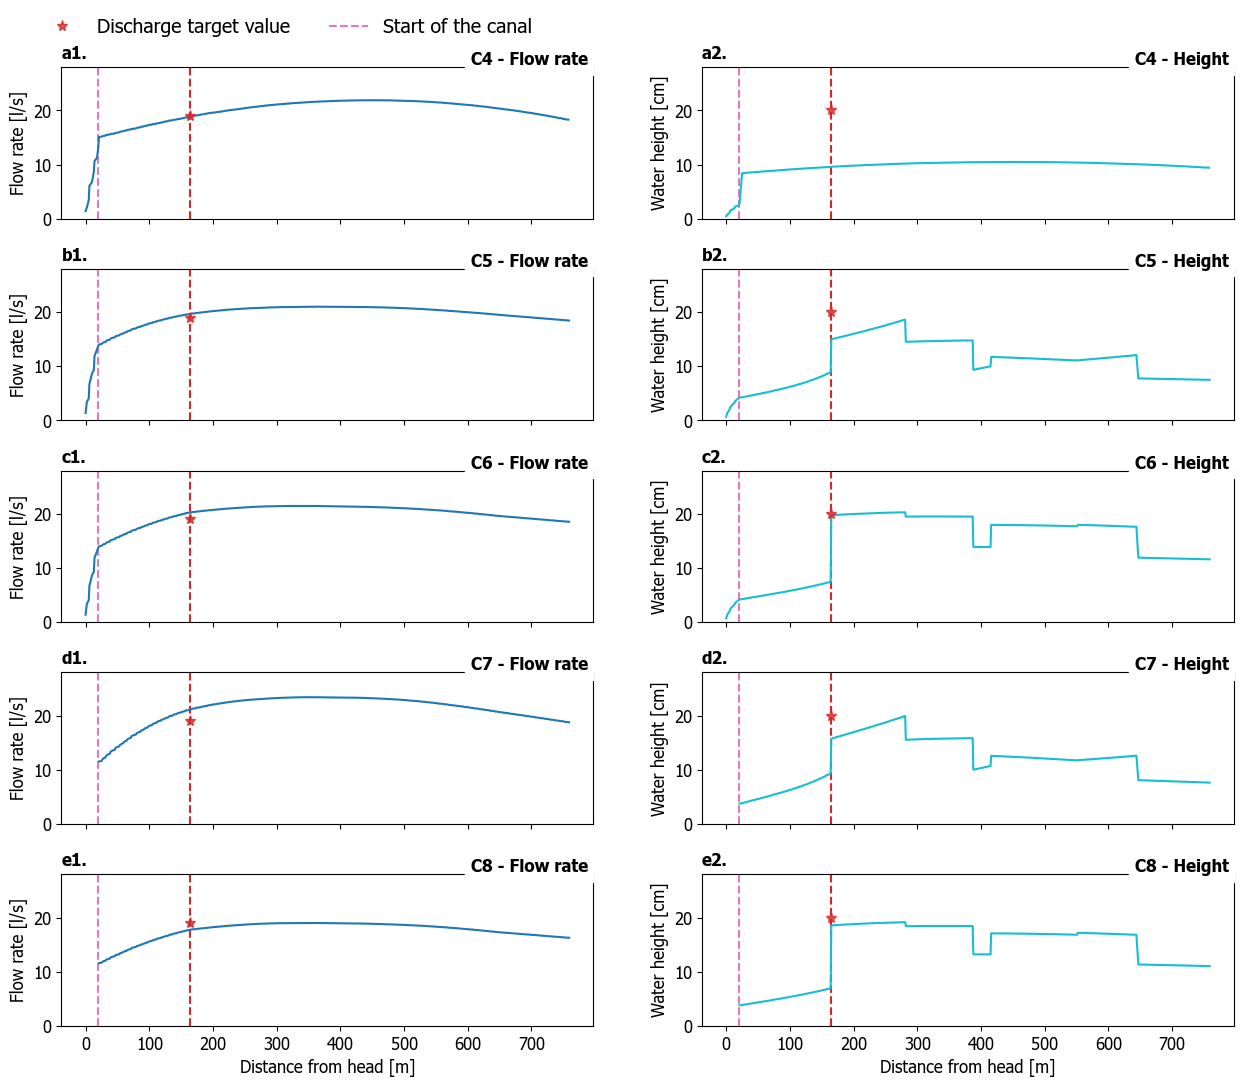

In [59]:
reach_number = 164

titles = [
    'a1.', 'a2.',
    'b1.', 'b2.',
    'c1.', 'c2.',
    'd1.', 'd2.',
    'e1.', 'e2.'
]
tags = [
    'C4', 'C5', 'C6', 'C7', 'C8'
]


fig, axes = plt.subplots(5,2, figsize = cm2inch(16*2, 14*2), sharex= True)

for i, ax in enumerate(axes):
    ax[0].plot(flow.loc[:, 'rchlencum'], flow.iloc[:,i]*1000, color = 'tab:blue', zorder = 2) #trovare modo di plottare con 
    ax[1].plot(flow.loc[:, 'rchlencum'], height.iloc[:,i]*100, color = 'tab:cyan', zorder = 2)

    ax[0].plot(reach_number, 0.019*1000, '*', color = 'tab:red',
               label = 'Discharge target value', ms = 8, zorder = 3, alpha = 0.8)
    ax[1].plot(reach_number, 0.20*100, '*', color = 'tab:red',
               label = 'Water height target value', ms = 8, zorder = 2, alpha = 0.8)
    
    ax[0].set_ylim(0, 0.028*1000)
    ax[1].set_ylim(0, 0.28*100)

    ax[0].axvline(reach_number, linestyle = '--', color = 'tab:red', zorder = 1)
    ax[1].axvline(reach_number, linestyle = '--', color = 'tab:red', zorder = 1)

    ax[0].axvline(20, linestyle = '--', color = 'tab:pink', zorder = 1, label = 'Start of the canal')
    ax[1].axvline(20, linestyle = '--', color = 'tab:pink', zorder = 1, label = 'Start of the canal')

    ax[0].set_ylabel('Flow rate [l/s]')
    ax[1].set_ylabel('Water height [cm]')

    if i == 0:
        ax[0].legend(loc = (-0.05, 1.15), frameon = False, fontsize = 14, ncols = 2)

    ax[0].text(0.99, 1.1, f'{tags[i]} - Flow rate', horizontalalignment='right',   verticalalignment='top',
            transform=ax[0].transAxes, family = 'Tahoma', weight ='bold', backgroundcolor = 'white',
            fontsize = 12)
    ax[1].text(0.99, 1.1, f'{tags[i]} - Height', horizontalalignment='right',   verticalalignment='top',
            transform=ax[1].transAxes, family = 'Tahoma', weight ='bold', backgroundcolor = 'white',
            fontsize = 12)
    
for i, ax in enumerate(axes.flatten()):
    ax.set_title(titles[i], loc ='left', fontweight = 'bold', fontsize = 12)

axes[-1][0].set_xlabel("Distance from head [m]")
axes[-1][1].set_xlabel("Distance from head [m]")

plt.rcParams['font.family'] = 'Tahoma'
plt.rcParams['font.size'] = 12

fig.tight_layout()
fig.savefig(os.path.join(cwd, 'figures', 'Figure_7_v2.png'), dpi = 300,bbox_inches = 'tight',)

## Figure 8 - July models

In [8]:
flow = pd.read_excel(os.path.join(cwd, 'output_data', 'validation', 'flow_water_height_validation.xlsx'), sheet_name='flow')
height = pd.read_excel(os.path.join(cwd, 'output_data', 'validation', 'flow_water_height_validation.xlsx'), sheet_name='water_height')
flow_aq = pd.read_excel(os.path.join(cwd, 'output_data', 'validation', 'flow_water_height_validation.xlsx'), sheet_name='flow_aq')

In [9]:
flow_aq.loc[flow_aq.iloc[:,0] > 0, 'rchlencum'].iloc[0]

341

In [10]:
flow_aq.loc[flow_aq.iloc[:,0] > 0, 'C6_cal'].sum()

0.0029316315000000003

C:\Users\user\AppData\Local\Temp\ipykernel_21116\728443284.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0][0].legend(loc = (0,1.5), frameon = False, fontsize = 11, ncols = 2)
C:\Users\user\AppData\Local\Temp\ipykernel_21116\728443284.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0][1].legend(loc = (0,1.5), frameon = False, fontsize = 11, ncols =2)


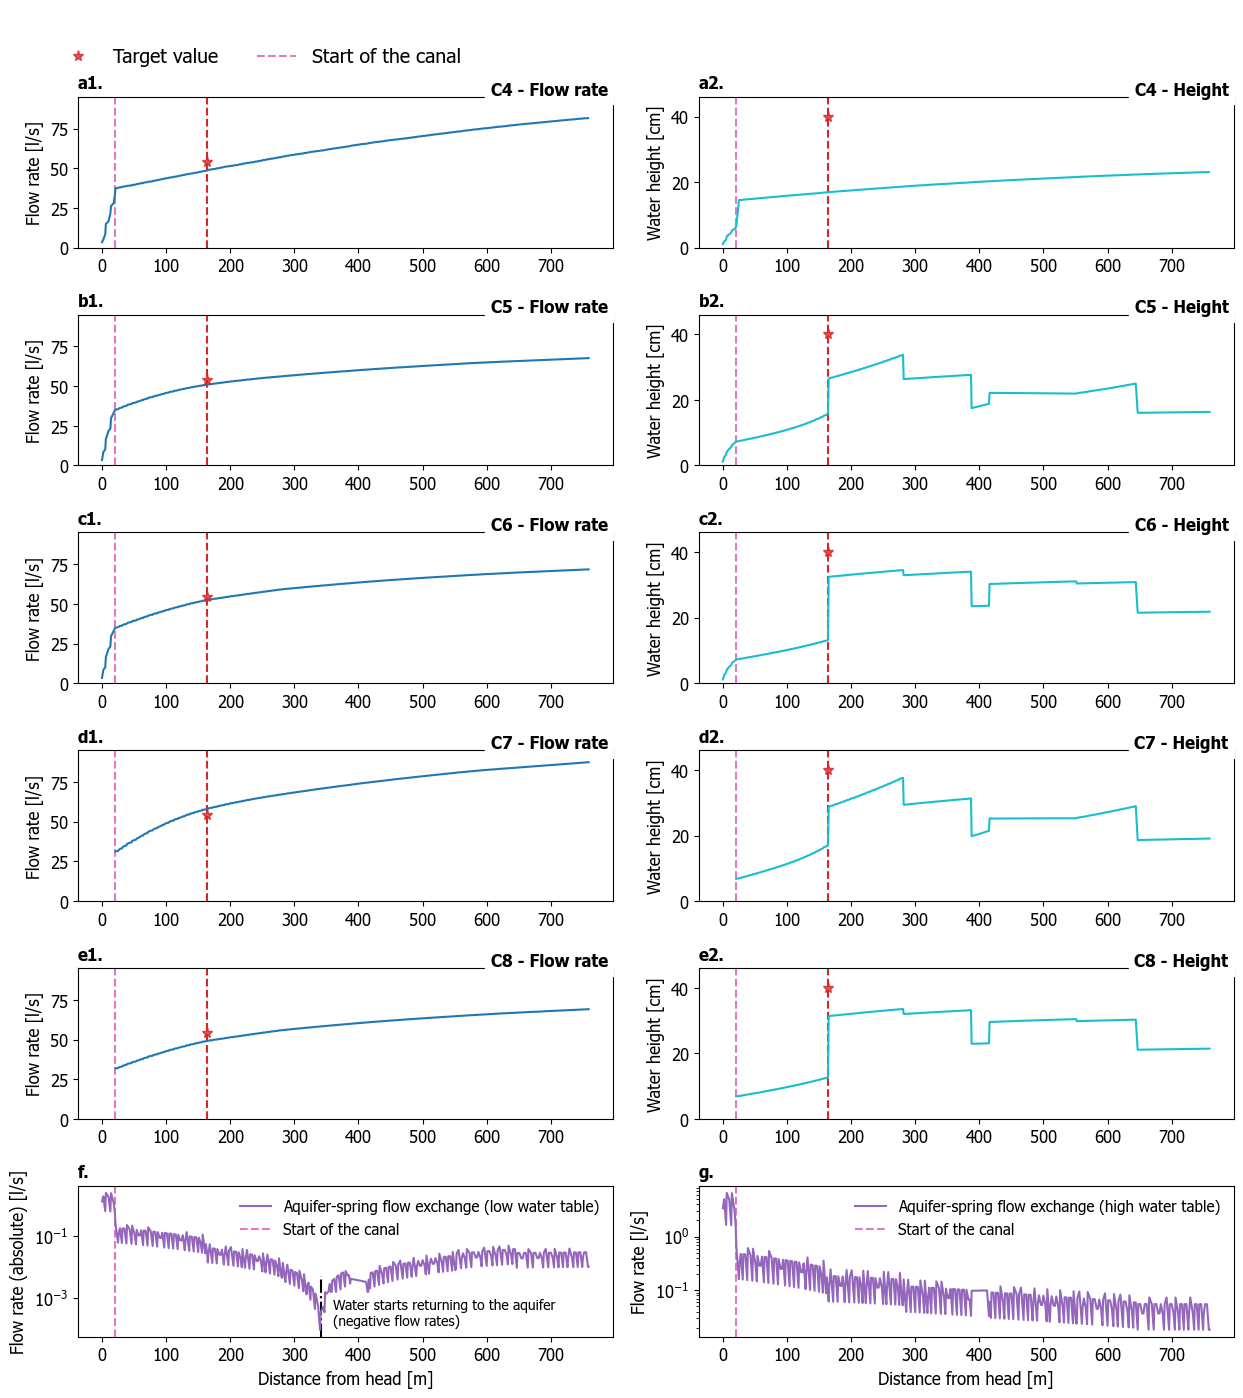

In [ ]:
reach_number = 164

titles = [
    'a1.', 'a2.',
    'b1.', 'b2.',
    'c1.', 'c2.',
    'd1.', 'd2.',
    'e1.', 'e2.'
]
tags = [
    'C4', 'C5', 'C6', 'C7', 'C8'
]

fig = plt.figure(figsize = cm2inch(16*2, 18*2))

gs = fig.add_gridspec(6,2)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1], sharex=ax1)
axes = [[ax1, ax2]]
for i in range(1,5):
    axes.append([fig.add_subplot(gs[i, 0], sharex=ax1), fig.add_subplot(gs[i, 1],sharex=ax1)])
ax3 = fig.add_subplot(gs[5, 0])
ax4 = fig.add_subplot(gs[5, 1])

for i, ax in enumerate(axes):
    ax[0].plot(flow.loc[:, 'rchlencum'], flow.iloc[:,i]*1000, color = 'tab:blue', zorder = 2) #trovare modo di plottare con 
    ax[1].plot(flow.loc[:, 'rchlencum'], height.iloc[:,i]*100, color = 'tab:cyan', zorder = 2)

    ax[0].plot(reach_number, 0.0541*1000, '*', color = 'tab:red',
               label = 'Target value', ms = 8, zorder = 3, alpha = 0.8)
    ax[1].plot(reach_number, 0.4*100, '*', color = 'tab:red',
               label = 'Water height target value', ms = 8, zorder = 2, alpha = 0.8)
    
    ax[0].set_ylim(0, 0.095*1000)
    ax[1].set_ylim(0, 0.46*100)

    ax[0].axvline(reach_number, linestyle = '--', color = 'tab:red', zorder = 1)
    ax[1].axvline(reach_number, linestyle = '--', color = 'tab:red', zorder = 1)

    ax[0].axvline(20, linestyle = '--', color = 'tab:pink', zorder = 1, label = 'Start of the canal')
    ax[1].axvline(20, linestyle = '--', color = 'tab:pink', zorder = 1, label = 'Start of the canal')

    ax[0].set_ylabel('Flow rate [l/s]')
    ax[1].set_ylabel('Water height [cm]')
    
    if i == 0:
        ax[0].legend(loc = (-0.05, 1.15), frameon = False, fontsize = 14, ncols = 2)

    ax[0].text(0.99, 1.1, f'{tags[i]} - Flow rate', horizontalalignment='right',   verticalalignment='top',
            transform=ax[0].transAxes, family = 'Tahoma', weight ='bold', backgroundcolor = 'white',
            fontsize = 12)
    ax[1].text(0.99, 1.1, f'{tags[i]} - Height', horizontalalignment='right',   verticalalignment='top',
            transform=ax[1].transAxes, family = 'Tahoma', weight ='bold', backgroundcolor = 'white',
            fontsize = 12)

for i, ax in enumerate(np.array(axes).flatten()):
    ax.set_title(titles[i], loc ='left', fontweight = 'bold', fontsize = 12)

# Plot flow to aquifer
tool = flow_aq.iloc[:,0]*-1000
tool.loc[flow_aq.iloc[:,0]*-1000 < 0] = tool.loc[flow_aq.iloc[:,0]*-1000 < 0].values * -1
ax3.semilogy(flow_aq.loc[:, 'rchlencum'], tool, color = 'tab:purple', zorder = 2, linewidth = 1.5, label = 'Aquifer-spring flow exchange (low water table)')
ax3.axhline(0, linestyle = '--', color = 'tab:gray', zorder = 1)
ax3.axvline(20, linestyle = '--', color = 'tab:pink', zorder = 1, label = 'Start of the canal')
ax3.axvline(341, ymax = 0.4, linestyle = '-.', color = 'k', zorder = 1)
ax3.legend(frameon = False, loc = 'upper right', fontsize = 11)

ax3.text(360, 10**-3, 'Water starts returning to the aquifer\n(negative flow rates)', horizontalalignment='left',
         verticalalignment='top', family = 'Tahoma', backgroundcolor = 'white',fontsize = 10)

ax4.semilogy(flow_aq.loc[:, 'rchlencum'], flow_aq.iloc[:,1]*-1000, color = 'tab:purple', zorder = 2, linewidth = 1.5, label = 'Aquifer-spring flow exchange (high water table)')
ax4.axhline(0, linestyle = '--', color = 'tab:gray', zorder = 1)
ax4.axvline(20, linestyle = '--', color = 'tab:pink', zorder = 1, label = 'Start of the canal')
ax4.legend(frameon = False, loc = 'upper right', fontsize = 11)

ax3.set_ylabel("Flow rate (absolute) [l/s]")
ax4.set_ylabel("Flow rate [l/s]")

ax3.set_xlabel("Distance from head [m]")
ax4.set_xlabel("Distance from head [m]")

ax3.set_title('f.', loc ='left', fontweight = 'bold', fontsize = 12)
ax4.set_title('g.', loc ='left', fontweight = 'bold', fontsize = 12)

plt.rcParams['font.family'] = 'Tahoma'
plt.rcParams['font.size'] = 12

fig.tight_layout()
fig.savefig(os.path.join(cwd, 'figures', 'Figure_8_v2.png'), dpi = 300, bbox_inches = 'tight',)

# Table 2: best performing models

come definire i best performing models?
- combined perc err


In [5]:
def is_pareto_efficient_simple(costs):
    """
    From: https://stackoverflow.com/a/40239615
    Find the pareto-efficient points
    :param costs: An (n_points, n_costs) array
    :return: A (n_points, ) boolean array, indicating whether each point is Pareto efficient
    """
    is_efficient = np.ones(costs.shape[0], dtype = bool)
    for i, c in enumerate(costs):
        if is_efficient[i]:
            is_efficient[is_efficient] = np.any(costs[is_efficient]<c, axis=1)  # Keep any point with a lower cost
            is_efficient[i] = True  # And keep self
    return is_efficient

In [6]:
mres = pd.read_csv(os.path.join(cwd, 'output_data', 'sfr_laksfr_complete_results_v3.csv'))
mres = mres.astype({"model": str,
             "package": str,
             "geom": str,
             "elev": str})
mres['code'] = [f'{m}_{p}' for m,p in zip(mres.model, mres.package)]

paretoidx = is_pareto_efficient_simple(mres.loc[:, ['flow_perc_err','depth_perc_err']].values)
pareto_front = mres.iloc[paretoidx,:].reset_index(drop=True).copy()

In [10]:
# Combined flow and depth
bestmodels = pareto_front.groupby(['package', 'geom', 'icalc'])['combined_perc_err'].idxmin().values
pareto_front.iloc[bestmodels,:].to_csv(os.path.join(cwd, 'output_data', 'best_models_pareto.csv'))

In [9]:
# Combined flow and depth
bestmodels = mres.groupby(['package', 'geom', 'icalc'])['combined_perc_err'].idxmin().values
mres.iloc[bestmodels,:].to_csv(os.path.join(cwd, 'output_data', 'best_models_allconfig.csv'))

## Calculations

In [ ]:
path = 'C:\repos\fontanile_model\output_data\C1_C3_results'